# D_S3.0 — Detection Power Analysis (Panel G / Panel B)

Two main figures (inspired by MIC / Reshef et al.):

1. **Panel G — Scatterplot grid**: rows = function families, columns = SNR levels
   (noiseless → noisy). Each cell shows a representative scatterplot with its
   permutation p-value annotated above.
2. **Panel B — p-value scatter**: x = SNR, y = p-value.
   Each point is one scatterplot case's p-value, showing how detection
   degrades as noise increases.

In [78]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S3_DIR = Path('output/S3')

## Load Data

In [ ]:
perm = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

meta_cols = ['case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
             'x_distribution', 'category', 'direction', 'linearity',
             'monotonicity', 'special_shape', 'replicate']
meta = cases[[c for c in meta_cols if c in cases.columns]].copy()

df = perm.merge(meta, on='case_id', how='left')
df['detected'] = (df['p_value'] <= 0.05).astype(int)

# Convert SNR to float for sorting
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

# Signal = all 24 families (not Null)
signal = df[df['family_id'] != 'Null'].copy()
null_df = df[df['category'] == 'true_null'].copy()

print(f'Total: {len(df):,} cases')
print(f'Signal (24 families): {len(signal):,}')
print(f'Null (true_null): {len(null_df):,}')
print(f'\nFamilies: {sorted(signal["family_id"].unique())}')
print(f'SNR levels: {signal["snr_val"].nunique()} unique values')
print(f'Replicates per (family, SNR): {signal.groupby(["family_id","snr"]).size().median():.0f}')

## Panel G — Scatterplot Grid with p-values

Rows = representative function families, Columns = SNR levels from noiseless to noisy.
Each cell shows a scatterplot with its permutation p-value annotated above
(green = detected, orange = uncertain, red = not detected).

In [ ]:
# ── Panel G: Scatterplot grid with p-values ──

repr_families = [
    ('F01', 'Linear'),
    ('F03', 'Power'),
    ('F07', 'Saturation'),
    ('F10', 'Logarithmic'),
    ('F13', 'S-curve'),
    ('F16', 'Exponential'),
    ('F17', 'Quadratic'),
    ('F18', 'U-shape'),
    ('F19', 'Spike'),
    ('F22', 'Oscillation'),
    ('F23', 'Two Lines'),
    ('F24', 'Line+Parabola'),
]

# ── SNR column selection ──
finite_snr = sorted([s for s in signal['snr_val'].unique() if np.isfinite(s)])
high_snr = [s for s in finite_snr if s >= 1.0]
trans_snr = [s for s in finite_snr if s < 1.0]

high_idx = np.round(np.linspace(0, len(high_snr) - 1, 2)).astype(int)
high_picks = [high_snr[i] for i in high_idx]

trans_idx = np.round(np.linspace(0, len(trans_snr) - 1, 3)).astype(int)
trans_picks = [trans_snr[i] for i in trans_idx]

snr_picks = [float('inf')] + sorted(set(high_picks + trans_picks), reverse=True)
print(f'SNR columns ({len(snr_picks)}): {["inf" if math.isinf(s) else f"{s:.4f}" for s in snr_picks]}')

# Load scatter points
pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

nrows = len(repr_families)
ncols = len(snr_picks)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.2 * nrows))

for ri, (fam_id, fam_label) in enumerate(repr_families):
    for ci, sv in enumerate(snr_picks):
        ax = axes[ri, ci]

        match = df[(df['family_id'] == fam_id) &
                   (df['snr_val'] == sv) &
                   (df['replicate'] == 0)]

        if len(match) > 0:
            row = match.iloc[0]
            idx = case_id_to_idx[row['case_id']]
            x, y = x_pts[idx], y_pts[idx]
            pv = row['p_value']

            ax.scatter(x, y, s=12, alpha=0.6, color='steelblue',
                       edgecolors='white', linewidths=0.3)

            if pv < 0.001:
                p_str = 'p<.001'
            else:
                p_str = f'p={pv:.4f}'
            p_color = '#2ca02c' if pv <= 0.05 else ('#ff7f0e' if pv < 0.10 else '#d62728')
            ax.set_title(p_str, fontsize=8, color=p_color, fontweight='bold', pad=2)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')

        if ri == 0:
            snr_lbl = 'SNR=∞' if math.isinf(sv) else f'SNR={sv:.3g}'
            ax.annotate(snr_lbl, xy=(0.5, 1.22), xycoords='axes fraction',
                        ha='center', fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'{fam_label}\n({fam_id})', fontsize=9, fontweight='bold')

        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Panel G — Scatterplot Grid with Permutation p-values\n'
             '(green p≤0.05 detected · orange uncertain · red p≥0.10 not detected)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del x_pts, y_pts

## Panel G2 — Metric Values on Scatterplot Grid

Same grid layout as Panel G, but each cell annotates the **observed values**
of three key metrics: dcor, LOWESS R², and MIC.

In [ ]:
# ── Panel G2: Scatterplot grid with dcor / LOWESS R² / MIC values ──

repr_families = [
    ('F01', 'Linear'),
    ('F03', 'Power'),
    ('F07', 'Saturation'),
    ('F10', 'Logarithmic'),
    ('F13', 'S-curve'),
    ('F16', 'Exponential'),
    ('F17', 'Quadratic'),
    ('F18', 'U-shape'),
    ('F19', 'Spike'),
    ('F22', 'Oscillation'),
    ('F23', 'Two Lines'),
    ('F24', 'Line+Parabola'),
]

finite_snr = sorted([s for s in signal['snr_val'].unique() if np.isfinite(s)])
high_snr = [s for s in finite_snr if s >= 1.0]
trans_snr = [s for s in finite_snr if s < 1.0]
high_idx = np.round(np.linspace(0, len(high_snr) - 1, 2)).astype(int)
high_picks = [high_snr[i] for i in high_idx]
trans_idx = np.round(np.linspace(0, len(trans_snr) - 1, 3)).astype(int)
trans_picks = [trans_snr[i] for i in trans_idx]
snr_picks = [float('inf')] + sorted(set(high_picks + trans_picks), reverse=True)

pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

nrows = len(repr_families)
ncols = len(snr_picks)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.6 * nrows))

for ri, (fam_id, fam_label) in enumerate(repr_families):
    for ci, sv in enumerate(snr_picks):
        ax = axes[ri, ci]

        match = df[(df['family_id'] == fam_id) &
                   (df['snr_val'] == sv) &
                   (df['replicate'] == 0)]

        if len(match) > 0:
            row = match.iloc[0]
            idx = case_id_to_idx[row['case_id']]
            x, y = x_pts[idx], y_pts[idx]

            ax.scatter(x, y, s=12, alpha=0.6, color='steelblue',
                       edgecolors='white', linewidths=0.3)

            dcor_v = row.get('dcor_obs', float('nan'))
            lowr_v = row.get('lowess_r2_obs', float('nan'))
            mic_v  = row.get('mic_obs', float('nan'))

            metric_str = (f'dcor={dcor_v:.3f}\n'
                          f'LOESS R²={lowr_v:.3f}\n'
                          f'MIC={mic_v:.3f}')
            ax.text(0.97, 0.03, metric_str, transform=ax.transAxes,
                    fontsize=7, fontfamily='monospace', va='bottom', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='#cccccc', alpha=0.85))

            pv = row['p_value']
            p_str = 'p<.001' if pv < 0.001 else f'p={pv:.4f}'
            p_color = '#2ca02c' if pv <= 0.05 else ('#ff7f0e' if pv < 0.10 else '#d62728')
            ax.set_title(p_str, fontsize=8, color=p_color, fontweight='bold', pad=2)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')

        if ri == 0:
            snr_lbl = 'SNR=∞' if math.isinf(sv) else f'SNR={sv:.3g}'
            ax.annotate(snr_lbl, xy=(0.5, 1.22), xycoords='axes fraction',
                        ha='center', fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'{fam_label}\n({fam_id})', fontsize=9, fontweight='bold')

        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Panel G2 — Scatterplot Grid with Metric Values (dcor · LOWESS R² · MIC)\n'
             '(p-value color: green ≤0.05 · orange <0.10 · red ≥0.10)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del x_pts, y_pts

## Panel B — p-value vs SNR (scatter)

Each point is one scatterplot case's permutation p-value.
x = SNR (log scale, strong→weak left to right), y = p-value.
Dashed line at α = 0.05.

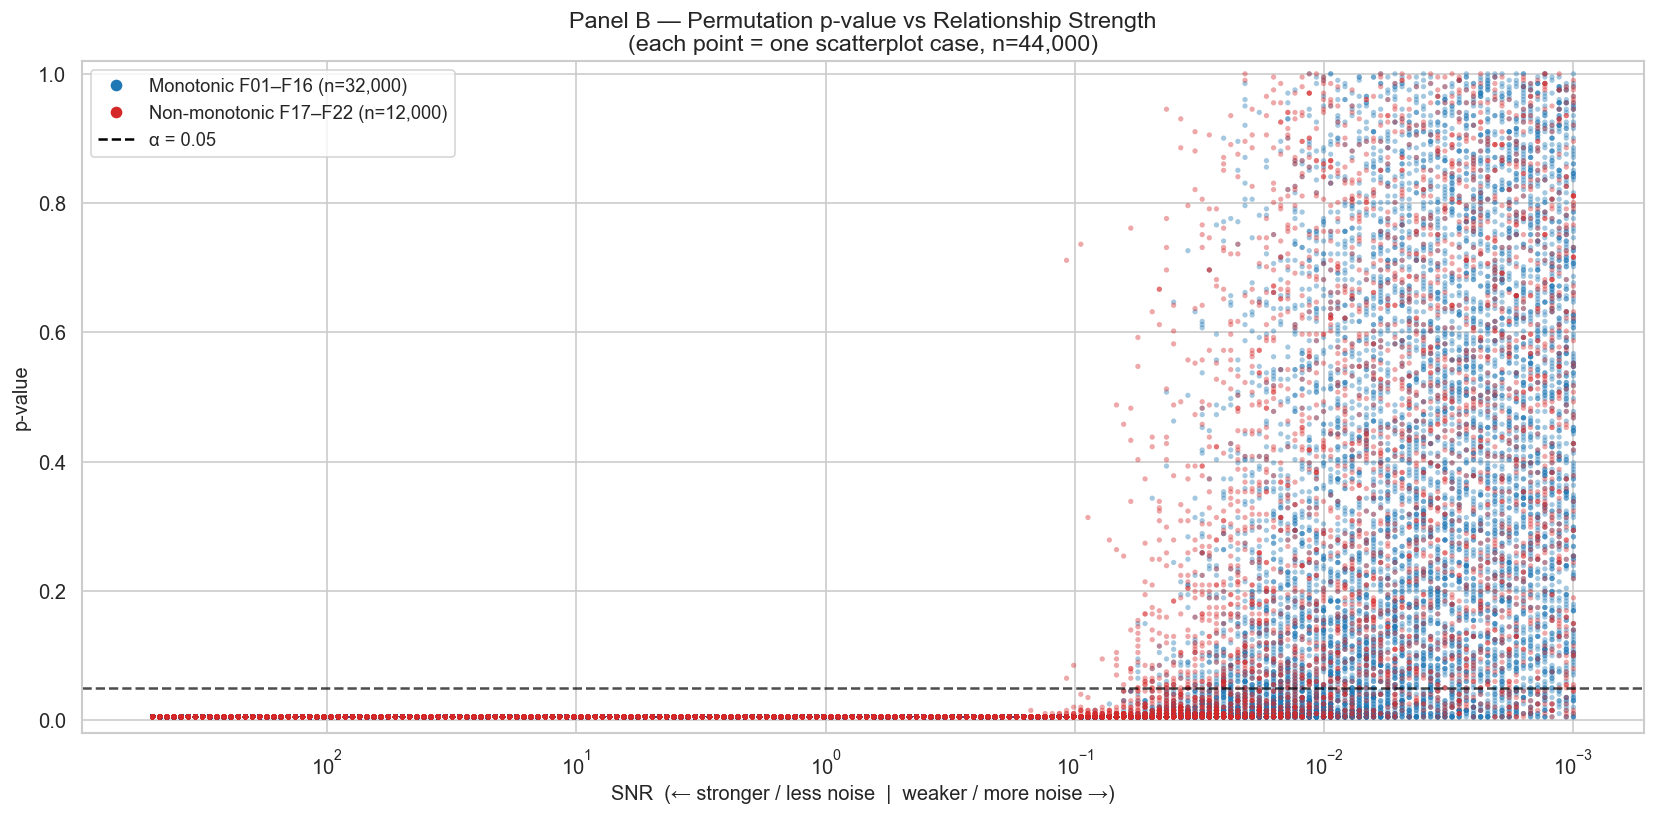


Points plotted: 44,000
  p ≤ 0.05 (detected): 35,405
  p > 0.05:            8,595


In [82]:
# ── Panel B: p-value scatter — every case as one dot ──

fig, ax = plt.subplots(figsize=(14, 7))

finite_signal = signal[np.isfinite(signal['snr_val'])].copy()

mono_mask = finite_signal['monotonicity'] == 'monotonic'
mono = finite_signal[mono_mask]
nonmono = finite_signal[~mono_mask]

ax.scatter(mono['snr_val'], mono['p_value'], s=10, alpha=0.4,
           color='#1f77b4', edgecolors='none', rasterized=True)
ax.scatter(nonmono['snr_val'], nonmono['p_value'], s=10, alpha=0.4,
           color='#d62728', edgecolors='none', rasterized=True)

ax.axhline(0.05, color='black', ls='--', lw=1.5, alpha=0.7)

ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('SNR  (← stronger / less noise  |  weaker / more noise →)', fontsize=12)
ax.set_ylabel('p-value', fontsize=12)
ax.set_title('Panel B — Permutation p-value vs Relationship Strength\n'
             f'(each point = one scatterplot case, n={len(finite_signal):,})',
             fontsize=14)
ax.set_ylim(-0.02, 1.02)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4',
           markersize=8, label=f'Monotonic F01–F16 (n={len(mono):,})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=8, label=f'Non-monotonic F17–F22 (n={len(nonmono):,})'),
    Line2D([0], [0], color='black', ls='--', lw=1.5, label='α = 0.05'),
]
ax.legend(handles=legend_handles, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print(f'\nPoints plotted: {len(finite_signal):,}')
print(f'  p ≤ 0.05 (detected): {(finite_signal["p_value"] <= 0.05).sum():,}')
print(f'  p > 0.05:            {(finite_signal["p_value"] > 0.05).sum():,}')

## Panel C — Metric Value vs SNR by Function Family

Each subplot = one metric. x = SNR (log scale), y = observed metric value.
Each dot = one case, coloured by function family (10 representative families).
Shows how each metric's raw signal degrades as noise increases.

## SNR Reference — What Does Each Noise Level Look Like?

A single row of scatterplots (F01 Linear) showing the same relationship
at 5 SNR levels, from noiseless (left) to nearly pure noise (right).

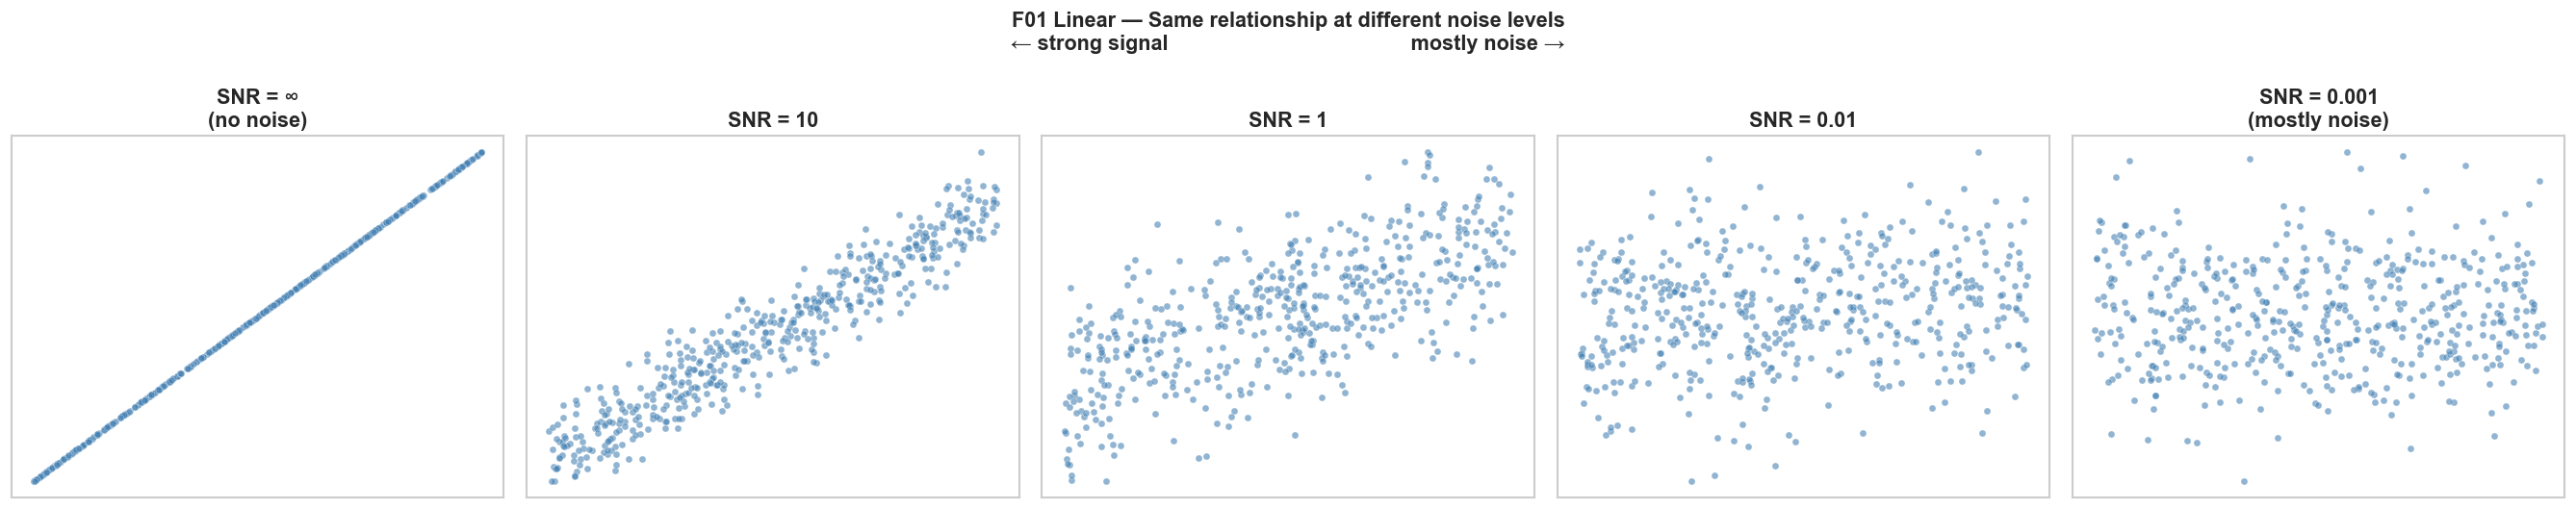

In [83]:
# ── SNR Reference: 5 scatterplots showing noise degradation ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

finite_snr = sorted([s for s in signal['snr_val'].unique() if np.isfinite(s)])
snr_ref = [float('inf')]
ref_targets = [10.0, 1.0, 0.01, 0.001]
for t in ref_targets:
    closest = min(finite_snr, key=lambda s: abs(s - t))
    snr_ref.append(closest)

fig, axes = plt.subplots(1, 5, figsize=(4.5 * 5, 4.5))

for ci, sv in enumerate(snr_ref):
    ax = axes[ci]
    match = df[(df['family_id'] == 'F01') &
               (df['snr_val'] == sv) &
               (df['replicate'] == 0)]
    if len(match) > 0:
        row = match.iloc[0]
        idx = case_id_to_idx[row['case_id']]
        x, y = x_pts[idx], y_pts[idx]
        ax.scatter(x, y, s=18, alpha=0.6, color='steelblue',
                   edgecolors='white', linewidths=0.3)

    snr_lbl = 'SNR = ∞\n(no noise)' if math.isinf(sv) else f'SNR = {sv:.2g}'
    if sv == snr_ref[-1]:
        snr_lbl += '\n(mostly noise)'
    ax.set_title(snr_lbl, fontsize=13, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('F01 Linear — Same relationship at different noise levels\n'
             '← strong signal                                          mostly noise →',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

del x_pts, y_pts

In [ ]:
# ── Panel C: Metric value vs SNR, coloured by function family ──

repr_fam_ids = ['F01','F03','F07','F10','F13','F16','F17','F18','F19','F22','F23','F24']
repr_fam_labels = {
    'F01': 'Linear',       'F03': 'Power',        'F07': 'Saturation',
    'F10': 'Logarithmic',  'F13': 'S-curve',      'F16': 'Exponential',
    'F17': 'Quadratic',    'F18': 'U-shape',      'F19': 'Spike',
    'F22': 'Oscillation',  'F23': 'Two Lines',    'F24': 'Line+Para',
}

metrics_to_plot = [
    ('abs_pearson_r_obs',   '|Pearson r|'),
    ('abs_spearman_rho_obs','|Spearman ρ|'),
    ('dcor_obs',            'Distance corr (dcor)'),
    ('lowess_r2_obs',       'LOWESS R²'),
    ('mic_obs',             'MIC'),
    ('mas_obs',             'MAS'),
    ('mev_obs',             'MEV'),
    ('mic_minus_r2_obs',    'MIC − r²'),
    ('ec_bin_eta2_obs',     'Binned η² (equal-count)'),
    ('ew_dist_wass_obs',    'Wasserstein (EW)'),
]

palette = plt.cm.tab20(np.linspace(0, 1, 12))
fam_colors = dict(zip(repr_fam_ids, palette))

finite_repr = signal[signal['family_id'].isin(repr_fam_ids) &
                     np.isfinite(signal['snr_val'])].copy()

ncols = 5
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.ravel()

for mi, (col, label) in enumerate(metrics_to_plot):
    ax = axes[mi]
    for fam_id in repr_fam_ids:
        sub = finite_repr[finite_repr['family_id'] == fam_id]
        vals = sub[col].dropna()
        if len(vals) == 0:
            continue
        ax.scatter(sub.loc[vals.index, 'snr_val'], vals, s=8, alpha=0.5,
                   color=fam_colors[fam_id], edgecolors='none',
                   label=f'{fam_id} {repr_fam_labels[fam_id]}',
                   rasterized=True)

    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.set_xlabel('SNR  (← stronger  |  weaker →)', fontsize=9)
    ax.set_ylabel(label, fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, 1.03), markerscale=2)

fig.suptitle('Panel C — Metric Value vs SNR by Function Family\n'
             '(left = strong relationship, right = buried in noise)',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

## Critical Threshold Examples

Scatterplots of cases near the decision boundaries of key metrics:
- **dcor ≈ 0.2**, **MIC ≈ 0.4**, **LOWESS R² ≈ 0.2**, **η² ≈ 0.01**

These show what a relationship "on the edge" of detection looks like for each metric.

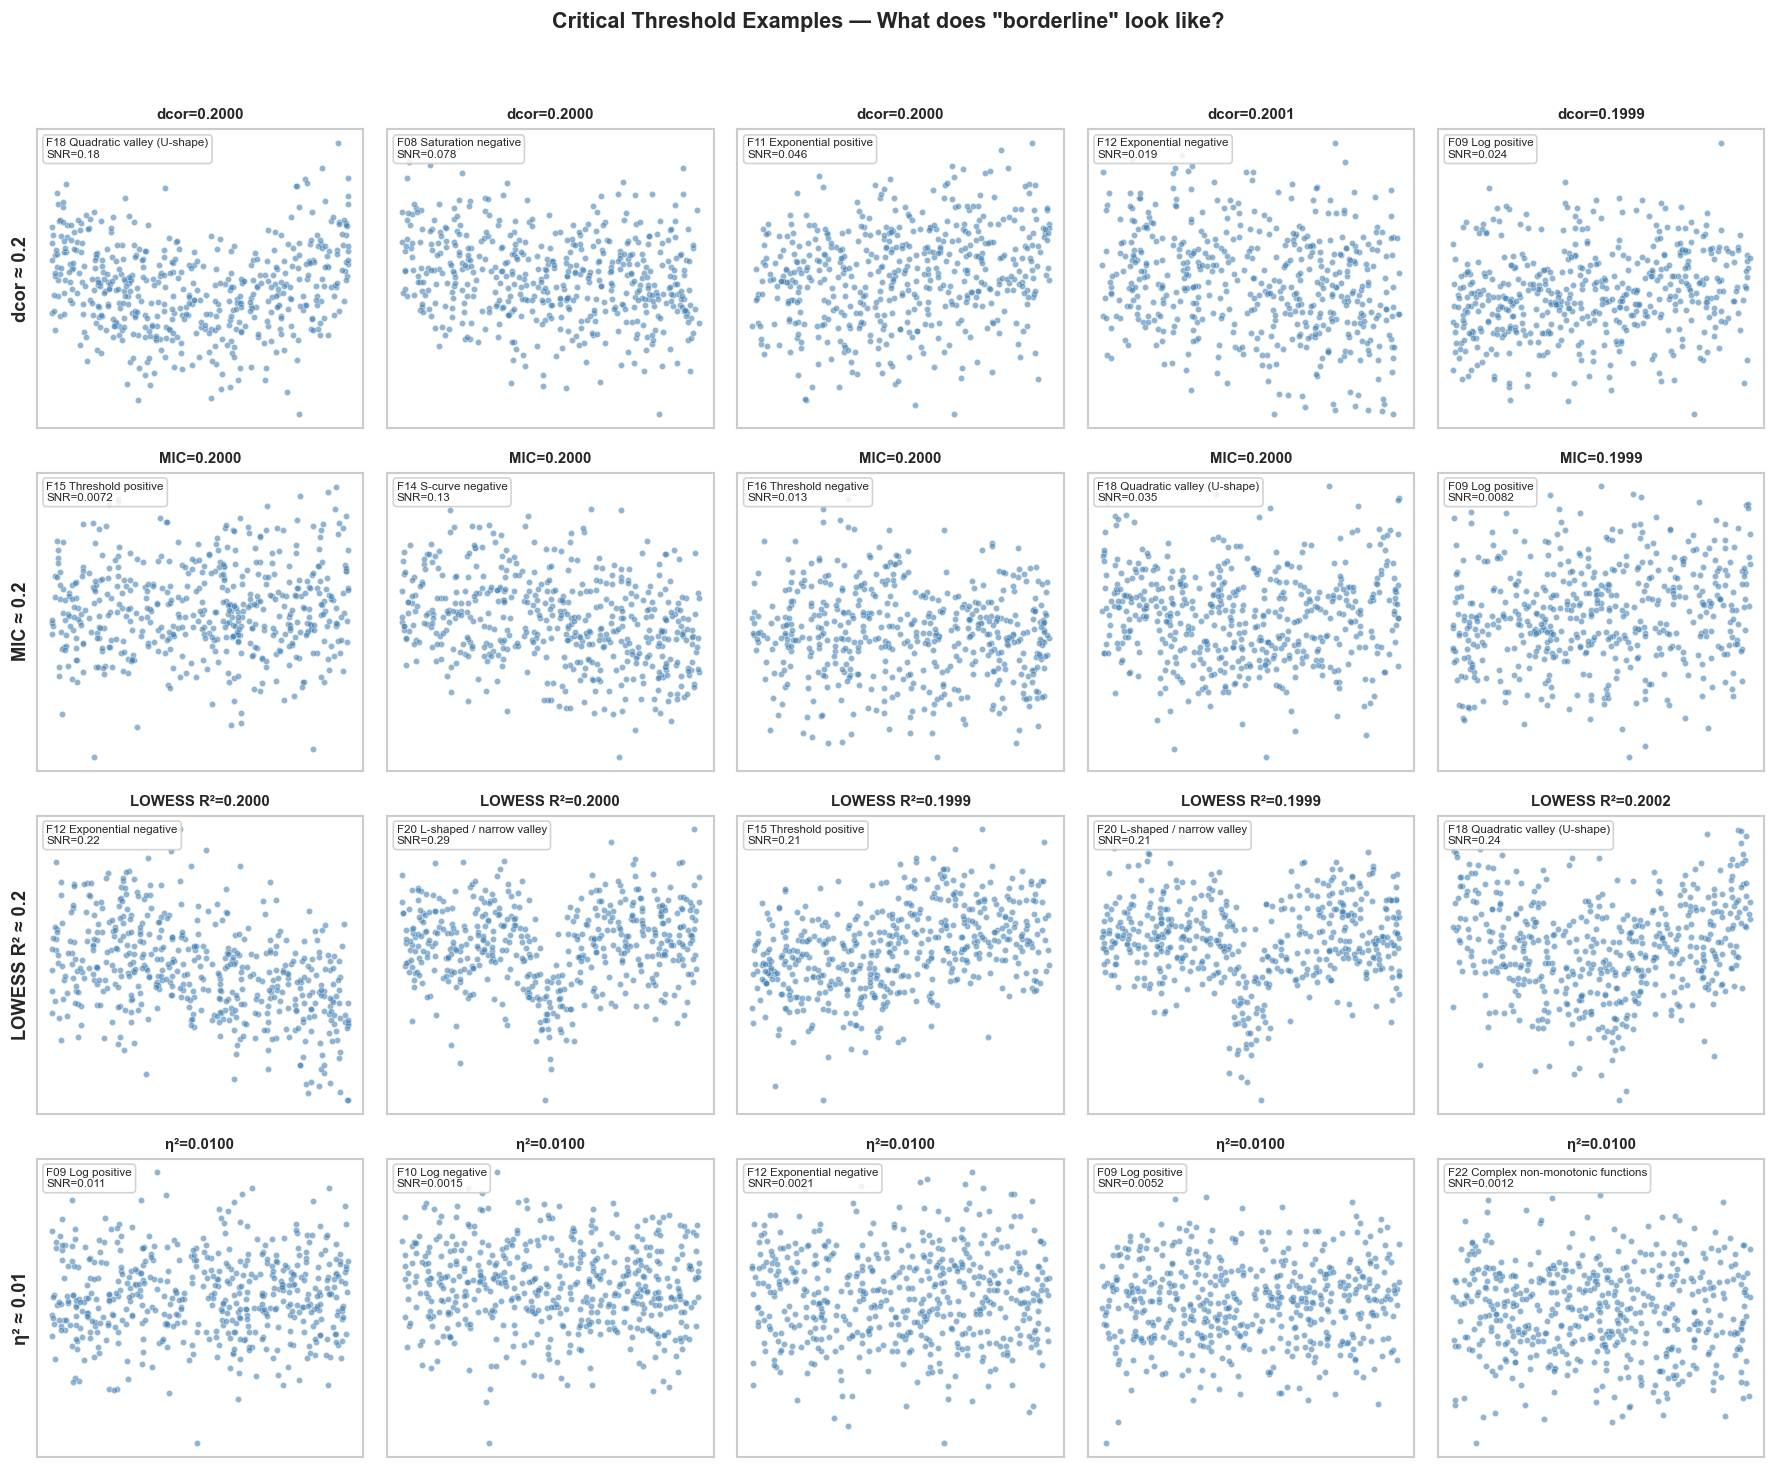

In [90]:
# ── Critical Threshold Examples: scatterplots near metric decision boundaries ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

thresholds = [
    ('dcor_obs',          'dcor',      0.2,  0.05),
    ('mic_obs',           'MIC',       0.2,  0.08),
    ('lowess_r2_obs',     'LOWESS R²', 0.2,  0.05),
    ('ec_bin_eta2_obs',   'η²',        0.01, 0.005),
]

n_examples = 5

fig, axes = plt.subplots(len(thresholds), n_examples,
                         figsize=(3.0 * n_examples, 3.0 * len(thresholds)))

for ri, (col, label, thresh, tol) in enumerate(thresholds):
    near = signal[signal[col].between(thresh - tol, thresh + tol)].copy()
    near['dist_to_thresh'] = (near[col] - thresh).abs()
    near = near.sort_values('dist_to_thresh').head(n_examples)

    for ci in range(n_examples):
        ax = axes[ri, ci]
        if ci < len(near):
            row = near.iloc[ci]
            idx = case_id_to_idx[row['case_id']]
            x, y = x_pts[idx], y_pts[idx]

            ax.scatter(x, y, s=14, alpha=0.6, color='steelblue',
                       edgecolors='white', linewidths=0.3)

            val = row[col]
            ax.set_title(f'{label}={val:.4f}', fontsize=9, fontweight='bold')

            info = f"{row['family_id']} {row.get('family_name','')}\nSNR={row['snr_val']:.2g}"
            ax.text(0.03, 0.97, info, transform=ax.transAxes,
                    fontsize=7, va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='#ccc', alpha=0.85))
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')

        ax.set_xticks([])
        ax.set_yticks([])

    axes[ri, 0].set_ylabel(f'{label} ≈ {thresh}', fontsize=11, fontweight='bold')

fig.suptitle('Critical Threshold Examples — What does "borderline" look like?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del x_pts, y_pts

## Null Baseline — FPR Stability

In [ ]:
# ── Null: FPR should be ~5% regardless of SNR ──
# (Null has constant f(x)=0, so SNR controls noise via σ₀ = 1/√SNR)
null_fpr = (null_df['p_value'] <= 0.05).mean()
print(f'Null FPR: {null_fpr:.1%} (expected ~5%)')
print(f'Null cases: {len(null_df):,}')

## Summary

In [87]:
# ── Summary ──
signal_det = (signal['p_value'] <= 0.05).mean()
null_fpr_val = (null_df['p_value'] <= 0.05).mean()

print('=' * 60)
print('D EXPERIMENT — SUMMARY')
print('=' * 60)
print(f'Total cases:            {len(df):,}')
print(f'Signal families:        {signal["family_id"].nunique()}')
print(f'SNR levels:             {signal["snr_val"].nunique()}')
print(f'Replicates per SNR:     {int(signal.groupby(["family_id","snr"]).size().median())}')
print()
print(f'Overall signal detection rate (p≤0.05):  {signal_det:.1%}')
print(f'Null FPR (p≤0.05):                       {null_fpr_val:.1%}')
print()
print('Median p-value by family (across all SNR):')
med_p = signal.groupby('family_id')['p_value'].median().sort_values()
for fam, mp in med_p.items():
    print(f'  {fam:4s}  median p = {mp:.4f}')

D EXPERIMENT — SUMMARY
Total cases:            44,300
Signal families:        22
SNR levels:             201
Replicates per SNR:     10

Overall signal detection rate (p≤0.05):  80.6%
Null FPR (p≤0.05):                       0.0%

Median p-value by family (across all SNR):
  F01   median p = 0.0050
  F20   median p = 0.0050
  F19   median p = 0.0050
  F18   median p = 0.0050
  F17   median p = 0.0050
  F16   median p = 0.0050
  F15   median p = 0.0050
  F14   median p = 0.0050
  F13   median p = 0.0050
  F12   median p = 0.0050
  F11   median p = 0.0050
  F10   median p = 0.0050
  F09   median p = 0.0050
  F08   median p = 0.0050
  F07   median p = 0.0050
  F06   median p = 0.0050
  F05   median p = 0.0050
  F04   median p = 0.0050
  F03   median p = 0.0050
  F02   median p = 0.0050
  F21   median p = 0.0050
  F22   median p = 0.0050


## Gallery — Diverse Scatterplot Samples

A 3×4 grid (12 plots) sampling different function families and noise levels,
giving a quick visual sense of the variety of shapes in the dataset.

In [ ]:
# ── Gallery: diverse scatterplots (6 families × 3 noise levels) ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

gallery_families = [
    ('F01', 'Linear'),
    ('F07', 'Saturation'),
    ('F17', 'Quadratic'),
    ('F22', 'Oscillation'),
    ('F23', 'Two Lines'),
    ('F24', 'Line+Parabola'),
]

finite_snr = sorted([s for s in signal['snr_val'].unique() if np.isfinite(s)])
gallery_snr = [
    (float('inf'), 'No noise'),
    (min(finite_snr, key=lambda s: abs(s - 1.0)),  'Medium noise'),
    (min(finite_snr, key=lambda s: abs(s - 0.01)), 'Heavy noise'),
]

nrows = len(gallery_snr)
ncols = len(gallery_families)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.2 * nrows))

for ri, (sv, noise_label) in enumerate(gallery_snr):
    for ci, (fam_id, fam_label) in enumerate(gallery_families):
        ax = axes[ri, ci]

        match = df[(df['family_id'] == fam_id) &
                   (df['snr_val'] == sv) &
                   (df['replicate'] == 0)]

        if len(match) > 0:
            row = match.iloc[0]
            idx = case_id_to_idx[row['case_id']]
            x, y = x_pts[idx], y_pts[idx]
            ax.scatter(x, y, s=14, alpha=0.6, color='steelblue',
                       edgecolors='white', linewidths=0.3)

        if ri == 0:
            ax.set_title(f'{fam_label} ({fam_id})', fontsize=11, fontweight='bold')
        if ci == 0:
            snr_str = 'SNR=∞' if math.isinf(sv) else f'SNR={sv:.2g}'
            ax.set_ylabel(f'{noise_label}\n{snr_str}', fontsize=10, fontweight='bold')

        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Gallery — Diverse Scatterplot Samples\n'
             '(6 function families × 3 noise levels)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del x_pts, y_pts

## Preview — New Function Families (F23 & F24)

Quick preview of the two new families before re-running the full pipeline.
Generated inline with moderate noise (SNR ≈ 5) so the shape is visible but not perfectly clean.

In [ ]:
# ── Preview: F23 (Two Lines) and F24 (Line + Parabola) with noise ──

rng = np.random.default_rng(42)
n = 500

def f23_two_lines(x, slope1=2.0, slope2=-1.5, c=0.4):
    y_at_c = slope1 * c
    return np.where(x < c, slope1 * x, y_at_c + slope2 * (x - c))

def f24_line_parabola(x, slope=2.0, a=8.0, c=0.4):
    y_at_c = slope * c
    return np.where(x < c, slope * x, y_at_c - a * (x - c) ** 2)

funcs = [
    ('F23 — Two Lines',       f23_two_lines),
    ('F24 — Line + Parabola', f24_line_parabola),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, func) in zip(axes, funcs):
    x = rng.uniform(0, 1, n)
    y_clean = func(x)
    sigma = np.sqrt(np.var(y_clean) / 5.0)   # SNR ≈ 5
    y = y_clean + rng.normal(0, sigma, n)

    ax.scatter(x, y, s=14, alpha=0.6, color='steelblue',
               edgecolors='white', linewidths=0.3)

    x_line = np.linspace(0, 1, 300)
    ax.plot(x_line, func(x_line), 'r-', lw=1.5, alpha=0.5, label='true signal')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('New Function Families Preview (SNR ≈ 5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()